In [9]:
%pip install statsmodels
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf


   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ------------- -------------------------- 3.9/11.3 MB 21.2 MB/s eta 0:00:01
   --------------------------------- ------ 9.4/11.3 MB 24.0 MB/s eta 0:00:01
   ---------------------------------------- 11.3/11.3 MB 22.4 MB/s  0:00:00
   ---------------------------------------- 0.0/37.4 MB ? eta -:--:--
   ----- ---------------------------------- 5.2/37.4 MB 26.1 MB/s eta 0:00:02
   ----------- ---------------------------- 10.5/37.4 MB 26.2 MB/s eta 0:00:02
   ----------------- ---------------------- 16.0/37.4 MB 26.3 MB/s eta 0:00:01
   ------------------------- -------------- 23.6/37.4 MB 28.8 MB/s eta 0:00:01
   -------------------------------- ------- 30.4/37.4 MB 29.4 MB/s eta 0:00:01
   ------------------------------------- -- 35.4/37.4 MB 28.6 MB/s eta 0:00:01
   ---------------------------------------- 37.4/37.4 MB 26.8 MB/s  0:00:01

   ------ --------------------------------- 1/6 [scipy]
   ------ ------------

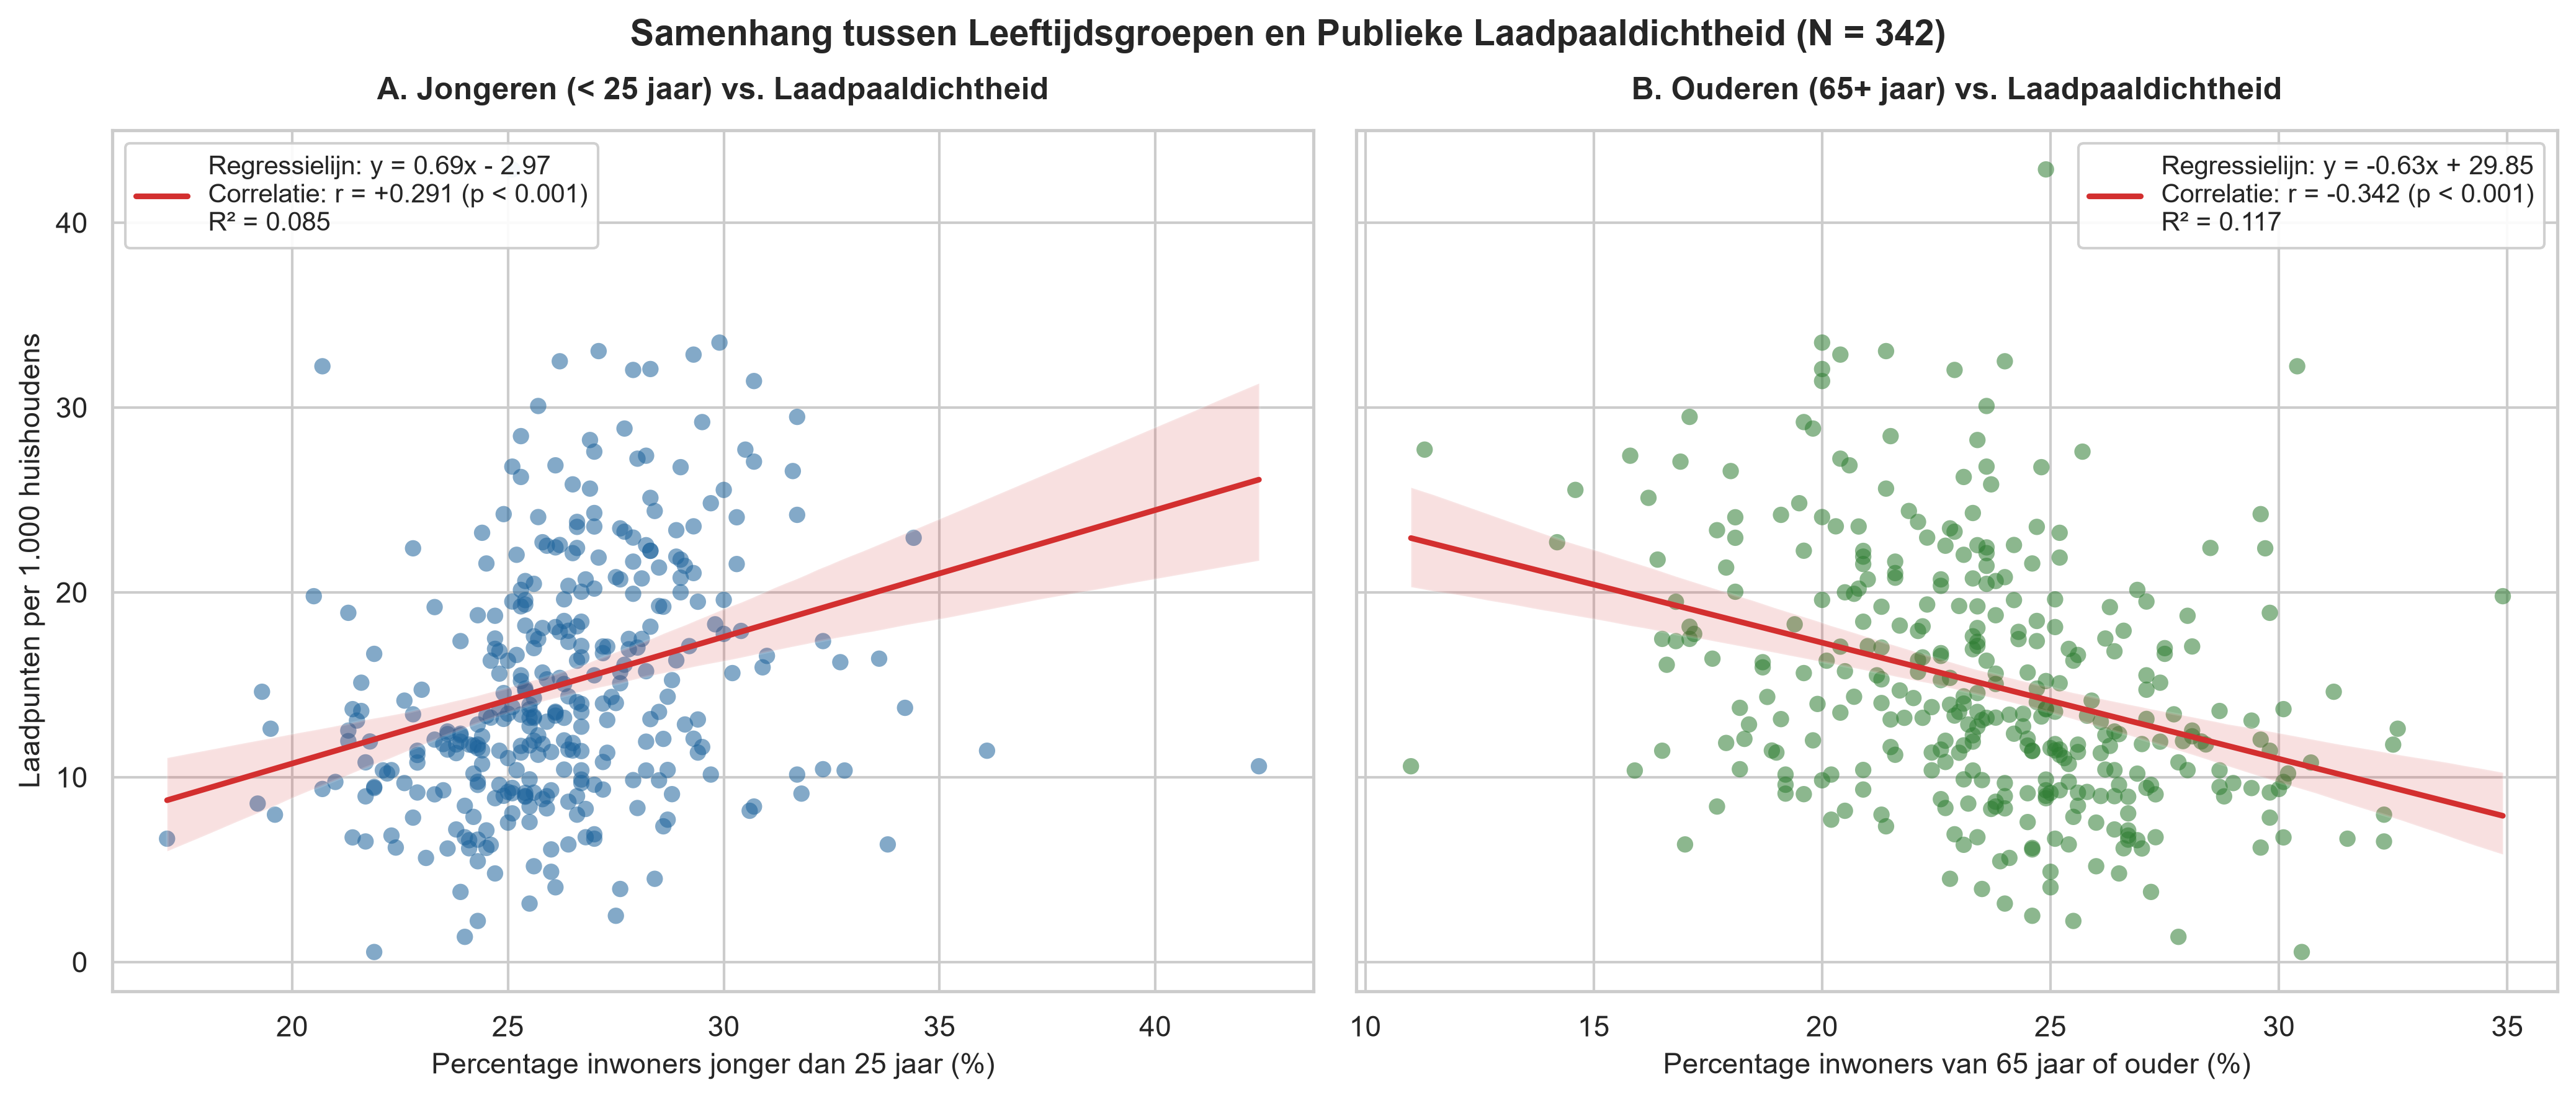

In [25]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Bestanden inlezen
df_laad = pd.read_csv("laadpunten_inkomen_per_gemeente (2).csv")
df_jong = pd.read_csv("Jongeren per gemeente, 2026 (%).csv", sep=";", decimal=",", encoding="utf-8-sig")
df_oud = pd.read_csv("Ouderen per gemeente, 2026 (%).csv", sep=";", decimal=",", encoding="utf-8-sig")

# 2. Gemeentenamen standaardiseren
cbs_mapping = {
    "'s-Gravenhage (gemeente)": "Den Haag",
    "Beek (L.)": "Beek",
    "Groningen (gemeente)": "Groningen",
    "Hengelo (O.)": "Hengelo",
    "Laren (NH.)": "Laren",
    "Middelburg (Z.)": "Middelburg",
    "Rijswijk (ZH.)": "Rijswijk",
    "Stein (L.)": "Stein",
    "Utrecht (gemeente)": "Utrecht"
}

df_jong_sub = pd.DataFrame({
    "gemeente": df_jong["Gemeente"].str.strip().replace(cbs_mapping),
    "jongeren_onder_25": df_jong["Totaal, 0 tot 25"]
})

df_oud_sub = pd.DataFrame({
    "gemeente": df_oud["Gemeente"].str.strip().replace(cbs_mapping),
    "ouderen_boven_65": df_oud["Totaal, 65 jaar of ouder"]
})

df_laad_sub = pd.DataFrame({
    "gemeente": df_laad["gemeente"].str.strip(),
    "laadpunten_per_1000_hh": df_laad.iloc[:, -1]
})

# 3. Samenvoegen
df = df_laad_sub.merge(df_jong_sub, on="gemeente").merge(df_oud_sub, on="gemeente")

# 4. Correlaties en p-waarden berekenen
r_j, p_j = stats.pearsonr(df['jongeren_onder_25'], df['laadpunten_per_1000_hh'])
r_o, p_o = stats.pearsonr(df['ouderen_boven_65'], df['laadpunten_per_1000_hh'])

# 5. Figuur opstellen
sns.set_theme(style="whitegrid", font="sans-serif")
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True, dpi=300)

# Links: Jongeren
sns.regplot(
    data=df,
    x='jongeren_onder_25',
    y='laadpunten_per_1000_hh',
    ax=axes[0],
    color='#1d639b',
    scatter_kws={'alpha': 0.55, 's': 40, 'edgecolor': 'none'},
    line_kws={'color': '#d32f2f', 'linewidth': 2.2, 
              'label': f'Regressielijn: y = 0.69x - 2.97\nCorrelatie: r = +{r_j:.3f} (p < 0.001)\nR² = 0.085'}
)
axes[0].set_title('A. Jongeren (< 25 jaar) vs. Laadpaaldichtheid', fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel('Percentage inwoners jonger dan 25 jaar (%)', fontsize=11)
axes[0].set_ylabel('Laadpunten per 1.000 huishoudens', fontsize=11)
axes[0].legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.92, fontsize=10)

# Rechts: Ouderen
sns.regplot(
    data=df,
    x='ouderen_boven_65',
    y='laadpunten_per_1000_hh',
    ax=axes[1],
    color='#2e7d32',
    scatter_kws={'alpha': 0.55, 's': 40, 'edgecolor': 'none'},
    line_kws={'color': '#d32f2f', 'linewidth': 2.2, 
              'label': f'Regressielijn: y = -0.63x + 29.85\nCorrelatie: r = {r_o:.3f} (p < 0.001)\nR² = 0.117'}
)
axes[1].set_title('B. Ouderen (65+ jaar) vs. Laadpaaldichtheid', fontsize=12, fontweight='bold', pad=12)
axes[1].set_xlabel('Percentage inwoners van 65 jaar of ouder (%)', fontsize=11)
axes[1].set_ylabel('')
axes[1].legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.92, fontsize=10)

fig.suptitle('Samenhang tussen Leeftijdsgroepen en Publieke Laadpaaldichtheid (N = 342)', fontsize=14, fontweight='bold', y=0.98)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.savefig('figuur_correlatie_en_regressie.png', dpi=300, bbox_inches='tight')
plt.show()
